<a href="https://colab.research.google.com/github/DiliniSew/Deep-Learning_Mini-Project/blob/main/Master_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Loading

In [36]:
!pip install opendatasets

In [37]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jangedoo/utkface-new?datasetId=44109")
#{"username":"rpddsewwandi","key":"d0fb60c60bae0d7a83861a898162a399"}

Skipping, found downloaded files in "./utkface-new" (use force=True to force download)


In [38]:
import os
import pandas as pd
# Removed 'import random' as shuffling is no longer required

data_path = "/content/utkface-new/utkface_aligned_cropped/UTKFace"

image_paths = []
age_labels = []
gender_labels = []

if os.path.exists(data_path):
    print(f"Processing files in '{data_path}'...")
    for item in os.listdir(data_path):
        if item.endswith(".jpg") or item.endswith(".png"):
            # Filename format: age_gender_ethnicity_date.jpg.chip.jpg
            parts = item.split('_')
            if len(parts) >= 2:
                try:
                    age = int(parts[0])
                    gender = int(parts[1])
                    image_paths.append(os.path.join(data_path, item))
                    age_labels.append(age)
                    gender_labels.append(gender)
                except ValueError:
                    # Skip files with unparseable age/gender
                    continue

    print(f"Found {len(image_paths)} images.")

    # Create a DataFrame
    data = pd.DataFrame({
        'image': image_paths,
        'age': age_labels,
        'gender': gender_labels
    })

    print("\nFirst 5 entries of the DataFrame:")
    print(data.head())

else:
    print(f"Error: Directory '{data_path}' does not exist.")


Processing files in '/content/utkface-new/utkface_aligned_cropped/UTKFace'...
Found 23708 images.

First 5 entries of the DataFrame:
                                               image  age  gender
0  /content/utkface-new/utkface_aligned_cropped/U...   70       1
1  /content/utkface-new/utkface_aligned_cropped/U...    1       0
2  /content/utkface-new/utkface_aligned_cropped/U...   86       0
3  /content/utkface-new/utkface_aligned_cropped/U...   25       0
4  /content/utkface-new/utkface_aligned_cropped/U...   75       0


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   23708 non-null  object
 1   age     23708 non-null  int64 
 2   gender  23708 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


[Text(0.5, 1.0, 'Distribution of Age')]

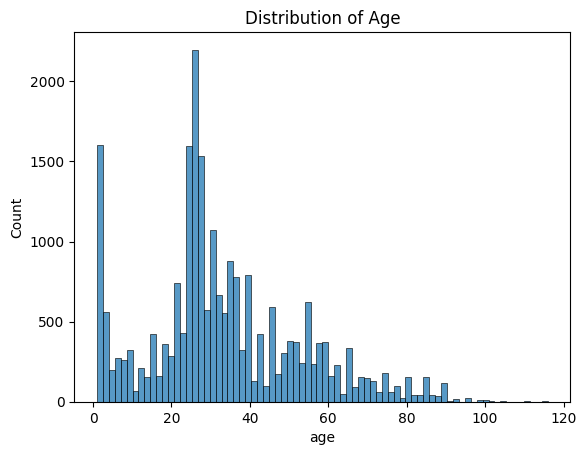

In [40]:
import seaborn as sns
sns.histplot(data.age).set(title="Distribution of Age")

[Text(0.5, 1.0, 'Distribution of Gender')]

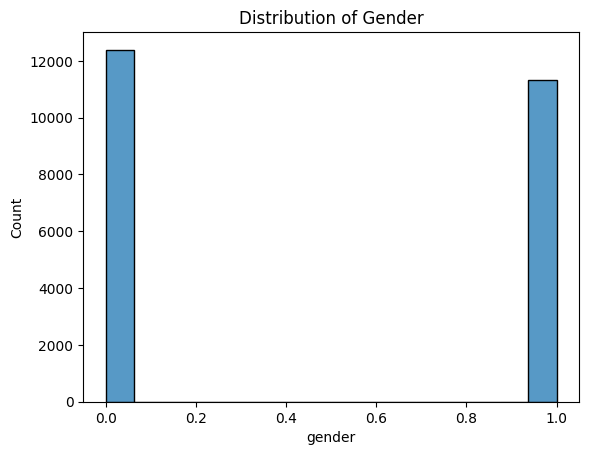

In [41]:
# Plotting the distribution of 'gender'
sns.histplot(data.gender).set(title="Distribution of Gender")

#Data Preprocessing

In [42]:
# Create a copy of the original DataFrame
data_shuffled = data.copy()

# Shuffle the copied DataFrame
data_shuffled = data_shuffled.sample(frac=1).reset_index(drop=True)

print("First 5 entries of the shuffled DataFrame:")
print(data_shuffled.head())


First 5 entries of the shuffled DataFrame:
                                               image  age  gender
0  /content/utkface-new/utkface_aligned_cropped/U...   78       0
1  /content/utkface-new/utkface_aligned_cropped/U...   62       1
2  /content/utkface-new/utkface_aligned_cropped/U...   69       1
3  /content/utkface-new/utkface_aligned_cropped/U...   45       1
4  /content/utkface-new/utkface_aligned_cropped/U...   21       1


In [43]:
print("Null values in the shuffled DataFrame:")
print(data_shuffled.isnull().sum())


Null values in the shuffled DataFrame:
image     0
age       0
gender    0
dtype: int64


# Data Analysis
Analyze the 'age' and 'gender' columns in the `data_shuffled` DataFrame to identify and visualize outliers or inconsistencies, specifically by examining the distribution of age, verifying gender values, and checking for unusual age-gender combinations.

## Analyze Age Distribution for Outliers




Descriptive statistics for 'age' column:
count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


[Text(0.5, 1.0, 'Box Plot of Age Distribution with Outliers')]

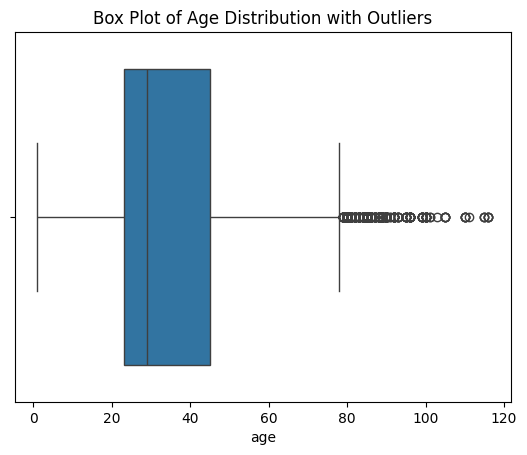

In [44]:
print("Descriptive statistics for 'age' column:")
print(data_shuffled['age'].describe())

# Create a box plot of the 'age' column to visualize outliers
sns.boxplot(x=data_shuffled['age']).set(title="Box Plot of Age Distribution with Outliers")

## Check for Inconsistent Gender Values





To verify that the 'gender' column only contains binary values (0 or 1).

In [45]:
print("Unique values in 'gender' column:")
print(data_shuffled['gender'].unique())

print("\nValue counts for 'gender' column:")
print(data_shuffled['gender'].value_counts())

Unique values in 'gender' column:
[0 1]

Value counts for 'gender' column:
gender
0    12391
1    11317
Name: count, dtype: int64


## Identify Extreme Age-Gender Combinations

Investigate if there are any data points with age and gender combinations that seem highly improbable or inconsistent (e.g., extreme ages associated with specific gender representations that could indicate data errors).


In [46]:
print("Descriptive statistics for 'age' grouped by 'gender':")
print(data_shuffled.groupby('gender')['age'].describe())

Descriptive statistics for 'age' grouped by 'gender':
          count       mean        std  min   25%   50%   75%    max
gender                                                             
0       12391.0  35.695666  19.705223  1.0  25.0  34.0  50.0  110.0
1       11317.0  30.684280  19.753650  1.0  21.0  26.0  37.0  116.0


To visually compare the age distributions for each gender and identify potential outliers, create side-by-side box plots of the 'age' column, separated by 'gender'.



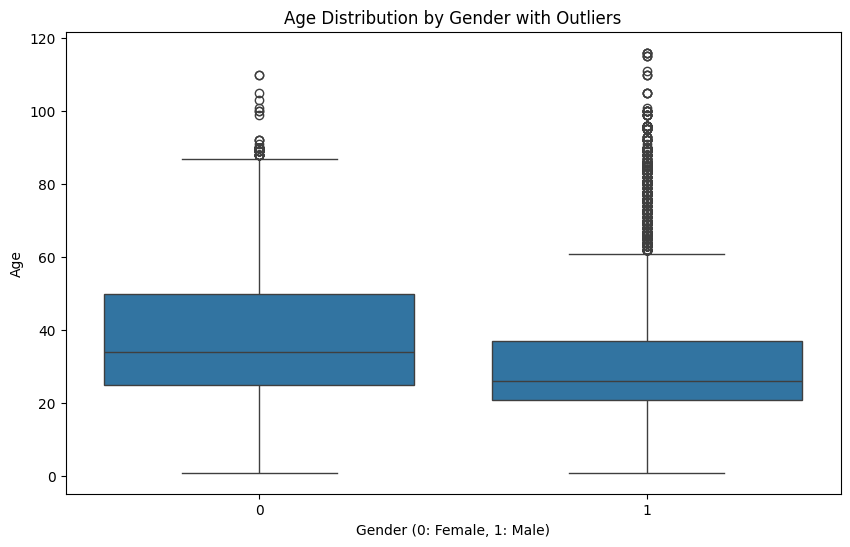

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='age', data=data_shuffled)
plt.title('Age Distribution by Gender with Outliers')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Age')
plt.show()

## Summary:

The analysis successfully identified and visualized potential outliers and inconsistencies in the 'age' and 'gender' columns.
*   **Age Distribution:** The 'age' column shows a wide range (1 to 116 years) with a right-skewed distribution, and a maximum age of 116 indicating potential outliers at the upper end.
*   **Gender Values:** The 'gender' column is consistent, containing only the expected binary values (0 and 1).
*   **Age-Gender Combinations:** While both gender groups exhibit a wide age range (up to 110 for gender 0 and 116 for gender 1), no immediately impossible or highly inconsistent age-gender combinations were identified.

### Data Analysis Key Findings
*   The 'age' column in `data_shuffled` has a mean of 33.30 and a median of 29.00, suggesting a right-skewed distribution.
*   A wide age range is observed, from a minimum of 1 year to a maximum of 116 years, with the maximum age potentially indicating outliers.
*   The 'gender' column contains only two unique values: 0 (12,391 occurrences) and 1 (11,317 occurrences), confirming consistency and the absence of unexpected entries.
*   When grouped by gender, the mean age for gender 0 is approximately 35.7 years (range 1-110), and for gender 1 is approximately 30.7 years (range 1-116).
*   No impossible age values (e.g., negative ages) or highly improbable age-gender combinations were found in the dataset, although the upper age limits of 110 and 116 are at the very high end of human lifespan.

